In [1]:
import os, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
%pip install lightgbm
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
print('라이브러리 로드 완료!')

Note: you may need to restart the kernel to use updated packages.
라이브러리 로드 완료!


e:\ML_CJE\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 데이터 경로 및 라벨 정리  

In [3]:
# 경로 설정 및 라벨 로드
import os
import pandas as pd

# 경로 설정 (E 드라이브 절대 경로)
BASE_DIR = r'E:\ML_CJE'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train')
LABEL_PATH = os.path.join(BASE_DIR, 'train_labels.csv')

# 라벨 파일 로드
train_df = pd.read_csv(LABEL_PATH)
print(f"전체 데이터 수: {len(train_df)}")

전체 데이터 수: 220025


In [ ]:
import os, cv2, numpy as np, pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from sklearn.model_selection import train_test_split

# 1. 경로 설정
BASE_DIR = r'E:\ML_CJE'
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train')
CSV_PATH = os.path.join(BASE_DIR, 'train_labels.csv')
SAVE_DIR = os.path.join(BASE_DIR, 'split_data')
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# 2. 특징 추출 함수 (32개 특징)
def get_32_features(patch):
    f = []
    # 색상 (RGB, HSV, LAB)
    for space in [None, cv2.COLOR_BGR2HSV, cv2.COLOR_BGR2LAB]:
        target = patch if space is None else cv2.cvtColor(patch, space)
        f.extend(np.mean(target, axis=(0,1)).tolist())
        f.extend(np.std(target, axis=(0,1)).tolist())
    # 질감 (GLCM)
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        f.append(graycoprops(glcm, prop)[0, 0])
    # 패턴 (LBP)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0,10), density=True)
    f.extend(hist.tolist())
    return np.array(f, dtype=np.float32)

# 3. 타일링 + 맥스 풀링 함수 (96x96 전용)
def extract_96x96(img_id, label, data_dir):
    # 확장자가 중복되지 않도록 처리
    full_id = str(img_id) if str(img_id).endswith('.tif') else f"{img_id}.tif"
    img_path = os.path.join(data_dir, full_id)
    img = cv2.imread(img_path)
    if img is None: return None
    
    tile_features = []
    for y in range(0, 96, 32):
        for x in range(0, 96, 32):
            tile = img[y:y+32, x:x+32]
            if np.mean(tile) > 240: continue # 배경 스킵
            tile_features.append(get_32_features(tile))
    
    final_f = np.max(np.array(tile_features), axis=0) if tile_features else get_32_features(img[32:64, 32:64])
    return (final_f, label) # 피처와 라벨을 묶어서 반환 (순서 보장)

# 4. 실행 및 분할 저장
print("🚀 22만 장 타일링 분석 시작...")
results = Parallel(n_jobs=-1)(delayed(extract_96x96)(row['id'], row['label'], TRAIN_IMG_DIR) 
                              for _, row in tqdm(df.iterrows(), total=len(df)))

# None 값(이미지 유실) 제외 처리
valid_results = [r for r in results if r is not None]
X = np.array([r[0] for r in valid_results])
y = np.array([r[1] for r in valid_results])

# [Step 5] 70:15:15 분할 및 저장
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

for name, data in zip(['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test'], 
                      [X_train, X_val, X_test, y_train, y_val, y_test]):
    np.save(os.path.join(SAVE_DIR, f'{name}.npy'), data)

print(f"✅ 데이터 분할 저장 완료! (Train: {len(X_train)})")

🚀 22만 장 타일링 분석 시작...


 50%|████▉     | 109408/220025 [33:07<31:48, 57.97it/s] 

# 데이터 분할  

In [11]:
from sklearn.model_selection import train_test_split
import numpy as np
import os

# 1. 경로 설정
BASE_DIR = r'E:\ML_CJE'

# 2. 전체 데이터 로드 (이미 생성된 X, y가 메모리에 있다면 바로 사용 가능)
# X = np.load(os.path.join(BASE_DIR, 'X_features.npy'))
# y = np.load(os.path.join(BASE_DIR, 'y_labels.npy'))

# 3. 데이터 분할 (70 : 30)
# 먼저 Train(70)과 나머지(30)로 나눕니다.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 4. 나머지(30)를 반으로 나누어 Val(15)과 Test(15)로 분할
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 5. 분할된 데이터를 각각 저장
save_path = os.path.join(BASE_DIR, 'split_data')
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, 'X_train.npy'), X_train)
np.save(os.path.join(save_path, 'X_val.npy'), X_val)
np.save(os.path.join(save_path, 'X_test.npy'), X_test)
np.save(os.path.join(save_path, 'y_train.npy'), y_train)
np.save(os.path.join(save_path, 'y_val.npy'), y_val)
np.save(os.path.join(save_path, 'y_test.npy'), y_test)

print(f"✅ 모든 데이터가 {save_path}에 분할 저장되었습니다.")

Train: (154017, 32), Val: (33004, 32), Test: (33004, 32)
✅ 모든 데이터가 E:\ML_CJE\split_data에 분할 저장되었습니다.


# 최종 선택  

In [14]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.6 MB 8.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.6 MB 9.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.6 MB 9.5 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.3 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ----------

In [ ]:
import numpy as np
import pandas as pd
import os
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# [Step 5] 데이터 불러오기
base_path = r'E:\ML_CJE\split_data'
X_train = np.load(os.path.join(base_path, 'X_train.npy'))
X_val = np.load(os.path.join(base_path, 'X_val.npy'))
X_test = np.load(os.path.join(base_path, 'X_test.npy'))
y_train = np.load(os.path.join(base_path, 'y_train.npy'))
y_val = np.load(os.path.join(base_path, 'y_val.npy'))
y_test = np.load(os.path.join(base_path, 'y_test.npy'))

# [Step 6 & 7] 다중공선성(VIF) 확인 및 제거 함수
def reduce_vif(X, threshold=10.0):
    df_vif = pd.DataFrame(X)
    curr_cols = list(range(df_vif.shape[1]))
    dropped = True
    
    while dropped:
        dropped = False
        vif_values = [variance_inflation_factor(df_vif.iloc[:, curr_cols].values, i) 
                      for i in range(len(curr_cols))]
        
        max_vif = max(vif_values)
        if max_vif > threshold:
            max_idx = vif_values.index(max_vif)
            print(f"Dropping column index {curr_cols[max_idx]} with VIF: {max_vif:.2f}")
            del curr_cols[max_idx]
            dropped = True
    return curr_cols

# Train 데이터 기준으로 제거할 컬럼 결정
selected_indices = reduce_vif(X_train)

# 모든 데이터셋에 동일한 컬럼 적용
X_train_vif = X_train[:, selected_indices]
X_val_vif = X_val[:, selected_indices]
X_test_vif = X_test[:, selected_indices]

print(f"최종 선택된 특징 개수: {len(selected_indices)}개")

Dropping column index 12 with VIF: 56299.38
Dropping column index 15 with VIF: 7160.57
Dropping column index 13 with VIF: 4673.32
Dropping column index 8 with VIF: 4289.75
Dropping column index 11 with VIF: 1223.27
Dropping column index 2 with VIF: 939.32
Dropping column index 3 with VIF: 857.21
Dropping column index 14 with VIF: 615.05
Dropping column index 31 with VIF: 500.90
Dropping column index 4 with VIF: 453.33
Dropping column index 0 with VIF: 405.54
Dropping column index 6 with VIF: 281.88
Dropping column index 23 with VIF: 201.01
Dropping column index 5 with VIF: 165.95
Dropping column index 29 with VIF: 126.29
Dropping column index 21 with VIF: 119.61
Dropping column index 1 with VIF: 92.65
Dropping column index 10 with VIF: 85.59
Dropping column index 30 with VIF: 83.59
Dropping column index 28 with VIF: 77.19
Dropping column index 24 with VIF: 70.86
Dropping column index 25 with VIF: 51.23
Dropping column index 19 with VIF: 40.59
Dropping column index 27 with VIF: 25.09
Dr

# 오버샘플링

In [16]:
# [Step 8] 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_vif)
X_val_scaled = scaler.transform(X_val_vif)
X_test_scaled = scaler.transform(X_test_vif)

# [Step 9] 오버샘플링 (SMOTE) - Train에만 적용!
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"오버샘플링 후 Train 데이터 크기: {len(X_train_res)}")

오버샘플링 후 Train 데이터 크기: 183270


In [17]:
# [Step 10] 여러 모델 비교
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_res, y_train_res)
    
    # Validation 세트로 예측 (튜닝 전 성능 확인)
    y_pred = model.predict(X_val_scaled)
    y_prob = model.predict_proba(X_val_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "AUC": roc_auc_score(y_val, y_prob)
    })

# 결과 표 출력
df_results = pd.DataFrame(results)
print("\n--- [모델 성능 비교 표 (Validation Set)] ---")
print(df_results.sort_values(by="F1-Score", ascending=False))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 91635, number of negative: 91635
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 183270, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

--- [모델 성능 비교 표 (Validation Set)] ---
                 Model  Accuracy  Precision    Recall  F1-Score       AUC
1        Random Forest  0.784935   0.722246  0.762118  0.741647  0.864177
2              XGBoost  0.772240   0.695176  0.779473  0.734916  0.857916
3             LightGBM  0.769149   0.694763  0.767056  0.729121  0.853403
0  Logistic Regression  0.678857   0.583772  0.721724  0.645459

# 하이퍼파라미터 튜닝

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import joblib

# 1. 튜닝 함수 정의
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**param)
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_val_scaled)
    return f1_score(y_val, preds) # F1-Score 극대화

# 2. 튜닝 시작
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10) # 22만 장이므로 10~20회

print(f"최적 파라미터: {study.best_params}")

# 3. 최적의 파라미터로 최종 모델 학습
best_model = RandomForestClassifier(**study.best_params, n_jobs=-1, random_state=42)
best_model.fit(X_train_res, y_train_res)

# 4. 모델 및 도구 저장 (.pkl) - 추후 streamlit에서 불러올 수 있도록
joblib.dump(best_model, 'final_rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selected_indices, 'selected_features.pkl') 
print("💾 모델 및 스케일러 저장 완료!")

최적 파라미터: {'n_estimators': 210, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1}
💾 모델 및 스케일러 저장 완료!


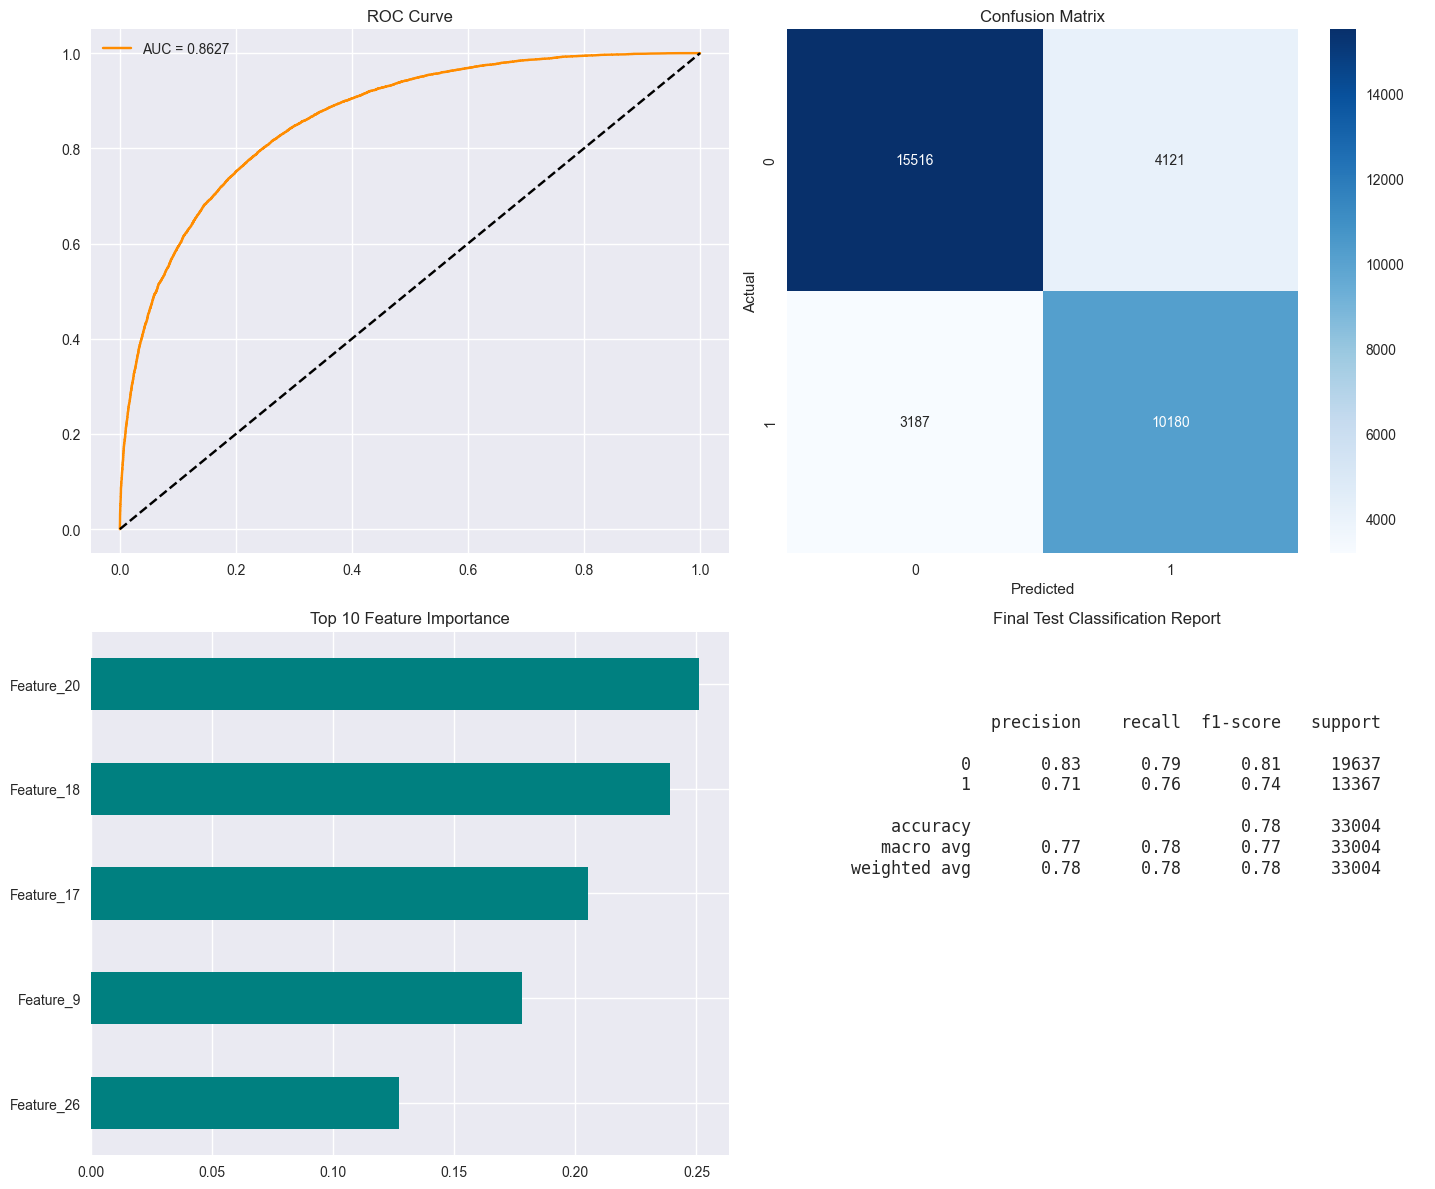

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# --- 시각화 설정 ---
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# 1) ROC Curve
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
# fpr: 거짓 양성률
# tpr: 진짜 양성률
ax[0, 0].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.4f}', color='darkorange')
ax[0, 0].plot([0, 1], [0, 1], 'k--')
ax[0, 0].set_title('ROC Curve')
ax[0, 0].legend()

# 2) Confusion Matrix (Heatmap)
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0, 1])
ax[0, 1].set_title('Confusion Matrix')
ax[0, 1].set_xlabel('Predicted')
ax[0, 1].set_ylabel('Actual')

# 3) Feature Importance (상위 10개)
# feature_names 리스트가 없다면 [f'F_{i}' for i in selected_indices] 사용
importances = pd.Series(best_model.feature_importances_, index=[f'Feature_{i}' for i in selected_indices])
importances.nlargest(10).sort_values().plot(kind='barh', ax=ax[1, 0], color='teal')
ax[1, 0].set_title('Top 10 Feature Importance')

# 4) 최종 리포트 출력
ax[1, 1].axis('off')
report = classification_report(y_test, y_pred)
ax[1, 1].text(0.1, 0.5, report, fontsize=12, family='monospace')
ax[1, 1].set_title('Final Test Classification Report')

plt.tight_layout()
plt.show()

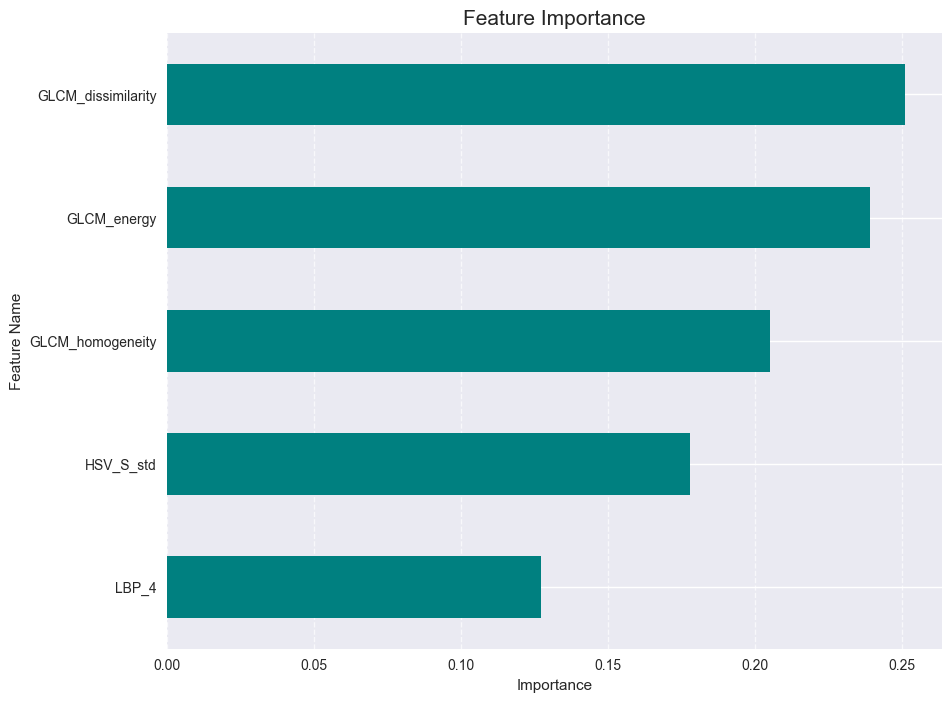

--- Feature Importance ---
GLCM_dissimilarity    0.250913
GLCM_energy           0.238951
GLCM_homogeneity      0.205069
HSV_S_std             0.177774
LBP_4                 0.127294
dtype: float64


In [21]:
# 1. 원본 32개 특징 이름 정의 (처음에 정했던 순서 그대로)
feature_names_orig = (
    ['RGB_B_mean','RGB_G_mean','RGB_R_mean','RGB_B_std','RGB_G_std','RGB_R_std'] +
    ['HSV_H_mean','HSV_S_mean','HSV_H_std','HSV_S_std'] +
    ['LAB_L_mean','LAB_a_mean','LAB_b_mean','LAB_L_std','LAB_a_std','LAB_b_std'] +
    ['GLCM_contrast','GLCM_homogeneity','GLCM_energy','GLCM_correlation',
     'GLCM_dissimilarity','GLCM_ASM'] +
    [f'LBP_{i}' for i in range(10)]
)

# 2. VIF로 선택된 인덱스에 해당하는 이름만 추출
# selected_indices는 [0, 2, 5, ...] 같은 형태의 리스트여야 합니다.
selected_feature_names = [feature_names_orig[i] for i in selected_indices]

# 3. 중요도 데이터프레임 생성
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 모델의 중요도와 이름을 매칭
feat_importances = pd.Series(best_model.feature_importances_, index=selected_feature_names)

# 4. 시각화
plt.figure(figsize=(10, 8))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance', fontsize=15)
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 5. 리스트로도 출력해서 확인
print("--- Feature Importance ---")
print(feat_importances.sort_values(ascending=False).head(10))

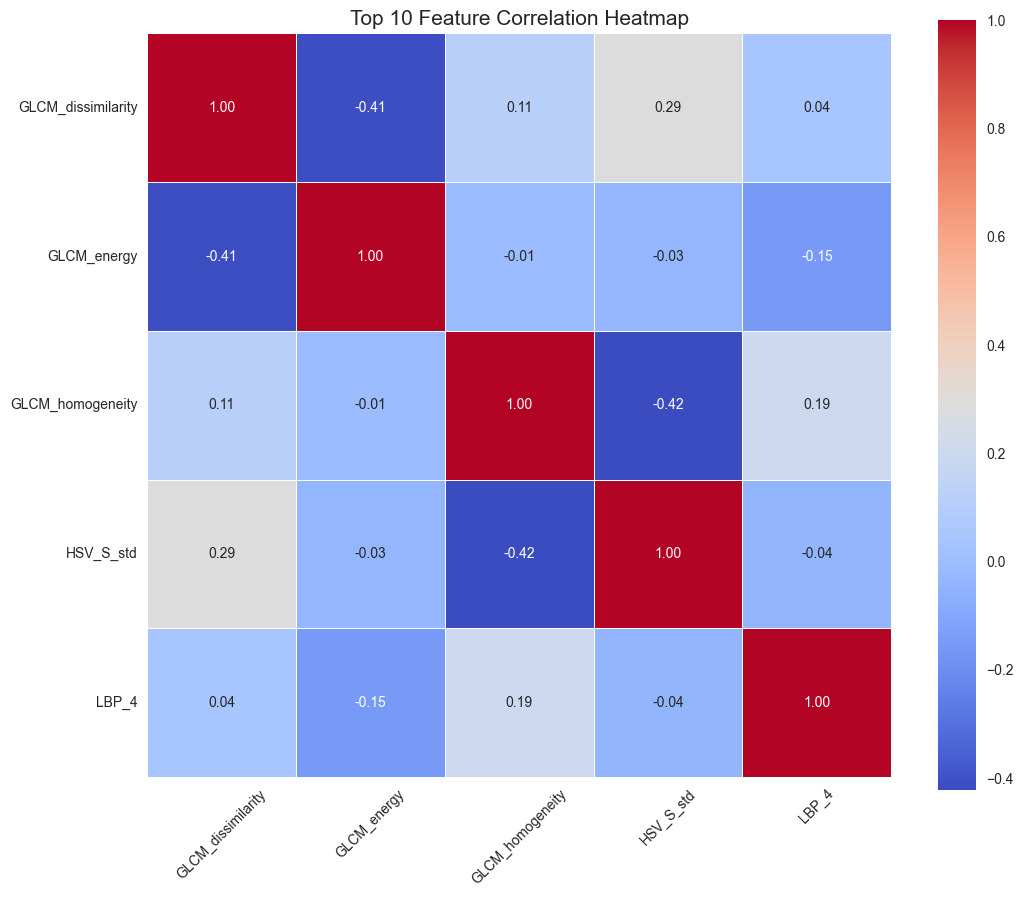

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. 상위 10개 특징 이름 추출
top_10_features = feat_importances.nlargest(10).index.tolist()

# 2. X_train_res(스케일링 및 오버샘플링 완료된 데이터)에서 상위 10개 컬럼만 추출
# 선택된 인덱스들 중에서 상위 10개 이름에 해당하는 인덱스 위치를 찾아야 함
top_10_indices = [selected_feature_names.index(name) for name in top_10_features]
df_top10 = pd.DataFrame(X_train_res[:, top_10_indices], columns=top_10_features)

# 3. 상관관계 행렬 계산
corr_matrix = df_top10.corr()

# 4. 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,          # 숫자 표시
            fmt=".2f",           # 소수점 둘째자리까지
            cmap='coolwarm',     # 파란색(음의 상관) ~ 빨간색(양의 상관)
            linewidths=0.5,      # 칸 사이 간격
            square=True)         # 정사각형 모양

plt.title('Top 10 Feature Correlation Heatmap', fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 혼동행렬

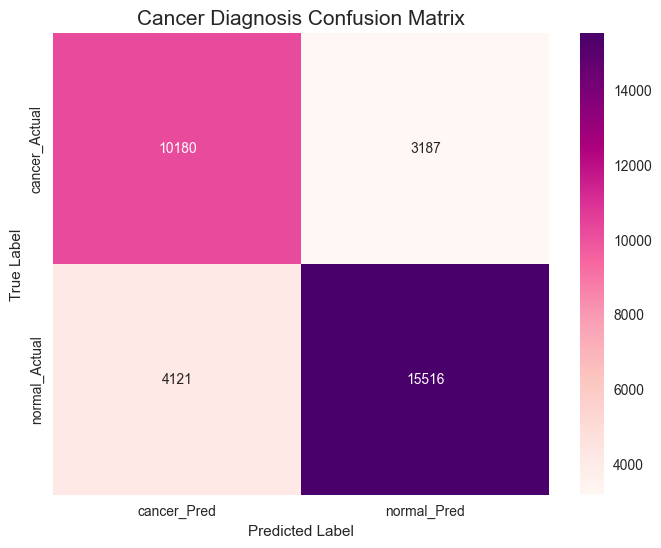

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.83      0.79      0.81     19637
      Cancer       0.71      0.76      0.74     13367

    accuracy                           0.78     33004
   macro avg       0.77      0.78      0.77     33004
weighted avg       0.78      0.78      0.78     33004



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. 예측값 생성
y_pred = best_model.predict(X_test_scaled)

# 2. 혼동행렬 계산
# labels=[1, 0] 순서로 설정하여 '암(Positive)'이 먼저 나오게 배치 (해석이 쉬워짐)
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])

# 3. 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['cancer_Pred', 'normal_Pred'],
            yticklabels=['cancer_Actual', 'normal_Actual'])

plt.title('Cancer Diagnosis Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# threshold: 0.5로 했을 때 암으로 예측한 것 중에서 실제로 암인 것의 비율 (정확도)
# precision: 정확한 것 (오탐)
# recall: 실제를 암이라고 예측한 것 (리탐)

# 4. 상세 리포트 출력
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Cancer']))

🏆 최종 TEST 세트 성적표 (임계값: 0.438)
Accuracy       : 0.7688
Precision      : 0.6782
Recall (재현율)   : 0.8169
F1-Score       : 0.7411
ROC-AUC        : 0.8627
--------------------------------------------------


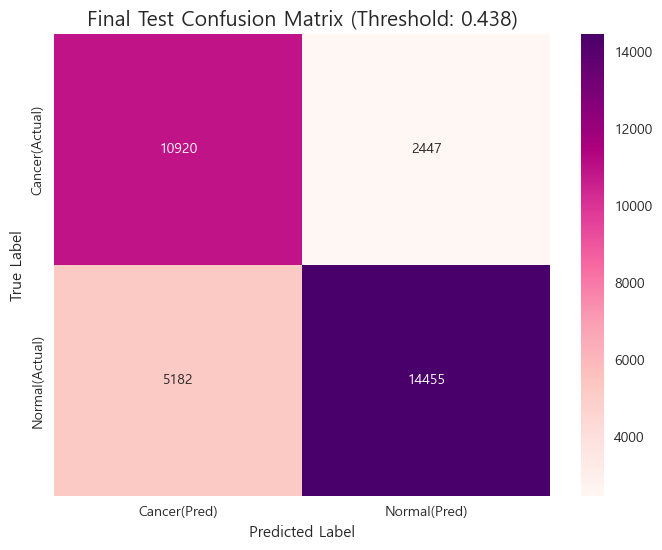


[상세 Classification Report]
              precision    recall  f1-score   support

      Normal       0.86      0.74      0.79     19637
      Cancer       0.68      0.82      0.74     13367

    accuracy                           0.77     33004
   macro avg       0.77      0.78      0.77     33004
weighted avg       0.78      0.77      0.77     33004



In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, 
    recall_score, precision_score, f1_score, roc_auc_score
)

# 1. 테스트 데이터 확률값 예측
y_test_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# 2. 최적 임계값(0.4380) 적용
final_threshold = 0.4380
y_test_pred = (y_test_probs > final_threshold).astype(int)

# 3. 최종 성능 지표 계산
metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall (재현율)": recall_score(y_test, y_test_pred),
    "F1-Score": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_probs)
}

# 4. 결과 출력
print("="*50)
print(f"🏆 최종 TEST 세트 성적표 (임계값: {final_threshold})")
print("="*50)
for key, value in metrics.items():
    print(f"{key:15}: {value:.4f}")
print("-" * 50)

# 5. 최종 혼동행렬 시각화
final_cm = confusion_matrix(y_test, y_test_pred, labels=[1, 0])
plt.figure(figsize=(8, 6))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Cancer(Pred)', 'Normal(Pred)'],
            yticklabels=['Cancer(Actual)', 'Normal(Actual)'])

plt.title(f'Final Test Confusion Matrix (Threshold: {final_threshold})', fontsize=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. 상세 리포트
print("\n[상세 Classification Report]")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Cancer']))

In [42]:
import joblib
import os

# 1. 파일 저장 실행
joblib.dump(best_model, 'final_rf_model.pkl')      # 최적화된 AI 모델
joblib.dump(scaler, 'scaler.pkl')                # 데이터의 '자(Scale)' 역할을 하는 스케일러
joblib.dump(selected_indices, 'selected_features.pkl') # 살아남은 정예 5인방의 인덱스

print("="*50)
print("💾 [저장 완료] Streamlit 배포를 위한 3종 세트가 준비되었습니다!")
print("="*50)

# 2. 파일이 제대로 있는지 확인 (안전장치)
for file in ['final_rf_model.pkl', 'scaler.pkl', 'selected_features.pkl']:
    if os.path.exists(file):
        print(f"✅ {file} (크기: {os.path.getsize(file)/1024:.2f} KB) - 준비 완료")
    else:
        print(f"❌ {file} - 저장 실패! 확인이 필요합니다.")

💾 [저장 완료] Streamlit 배포를 위한 3종 세트가 준비되었습니다!
✅ final_rf_model.pkl (크기: 644120.13 KB) - 준비 완료
✅ scaler.pkl (크기: 0.70 KB) - 준비 완료
✅ selected_features.pkl (크기: 0.03 KB) - 준비 완료


# 탐색적 데이터 분석 (EDA)

In [1]:
# 사전 설치 : pip install ydata-profiling==4.12.2 pandas==2.2.3 numpy==2.2.3
# 사전 폴더 생성 : report
import os
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

# 1. 데이터 불러오기 (분할 저장했던 npy 파일 로드)
SAVE_DIR = 'split_data'
X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))

# 2. 특징 이름 정의 (32개 원본 이름)
feature_names = [
    "RGB_R_mean", "RGB_G_mean", "RGB_B_mean", "RGB_R_std", "RGB_G_std", "RGB_B_std",
    "HSV_H_mean", "HSV_S_mean", "HSV_V_mean", "HSV_H_std", "HSV_S_std", "HSV_V_std",
    "LAB_L_mean", "LAB_A_mean", "LAB_B_mean", "LAB_L_std", "LAB_A_std", "LAB_B_std",
    "GLCM_contrast", "GLCM_homogeneity", "GLCM_energy", "GLCM_correlation",
    "LBP_0", "LBP_1", "LBP_2", "LBP_3", "LBP_4", "LBP_5", "LBP_6", "LBP_7", "LBP_8", "LBP_9"
]

# 3. 데이터프레임 생성
df = pd.DataFrame(X_train, columns=feature_names)
df['target'] = y_train  # 0: 정상, 1: 암

# 4. 보고서 생성 전 폴더 확인
os.makedirs('report', exist_ok=True)

# 5. YData Profiling 실행
# explorative=True 를 설정하면 상관관계와 상세 통계가 더 깊게 나옵니다.
profile = ProfileReport(
    df, 
    title="Cancer Cell Feature Profiling Report", 
    explorative=True,
    interactions={'targets': ['target']} # 타겟 변수 중심 분석 설정
)

# 6. 보고서 저장
output_file = 'report/cancer_eda_report.html'
profile.to_file(output_file)

print(f"✨ 분석 완료! 보고서 확인: {output_file}")

e:\ML_CJE\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 100.16it/s]

✨ 분석 완료! 보고서 확인: report/cancer_eda_report.html


In [2]:
# 사전 설치 : pip install ydata-profiling==4.12.2 pandas==2.2.3 numpy==2.2.3
import os
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

# 1. 데이터 불러오기
SAVE_DIR = 'split_data'
X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))

# 2. 전체 특징 이름 (참조용)
all_feature_names = [
    "RGB_R_mean", "RGB_G_mean", "RGB_B_mean", "RGB_R_std", "RGB_G_std", "RGB_B_std",
    "HSV_H_mean", "HSV_S_mean", "HSV_V_mean", "HSV_H_std", "HSV_S_std", "HSV_V_std",
    "LAB_L_mean", "LAB_A_mean", "LAB_B_mean", "LAB_L_std", "LAB_A_std", "LAB_B_std",
    "GLCM_contrast", "GLCM_homogeneity", "GLCM_energy", "GLCM_correlation",
    "LBP_0", "LBP_1", "LBP_2", "LBP_3", "LBP_4", "LBP_5", "LBP_6", "LBP_7", "LBP_8", "LBP_9"
]

# 3. 정예 5인방 인덱스 선택 및 데이터프레임 생성
# selected_indices = [9, 17, 18, 20, 26]
selected_indices = [9, 17, 18, 20, 26]
selected_names = [all_feature_names[i] for i in selected_indices]

# 데이터 슬라이싱
X_selected = X_train[:, selected_indices]
df_selected = pd.DataFrame(X_selected, columns=selected_names)
df_selected['is_cancer'] = y_train # 0: 정상, 1: 암

# 4. YData Profiling 실행 (정예 멤버 버전)
profile = ProfileReport(
    df_selected, 
    title="Top 5 Cancer Features Analysis", 
    explorative=True,
    interactions={'targets': ['is_cancer']} # 암 여부와의 관계 집중
)

# 5. 저장
os.makedirs('report', exist_ok=True)
output_file = 'report/top5_features_report.html'
profile.to_file(output_file)

print(f"✅ 정예 5인방 EDA 완료: {output_file}")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 200.18it/s]

✅ 정예 5인방 EDA 완료: report/top5_features_report.html


In [3]:
%pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------- ------------- 1.8/2.7 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.9 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.6/38.1 MB 7.6 MB/s eta 0:00:05
   -- ------------------------------------- 2.6/38.1 MB 6.9 MB/s eta 0:00:06
   --- ------------------------------------ 3.7/38.1 MB 6.2 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/38.1 MB 6.2 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/38.1 MB 6.7 MB/s eta 0:00:05
   --------- ------------------------------ 8.9/38.1 MB 7.1 MB/s eta 0:00:05
   ----------- ---------------------------- 10.7/38.1 MB 7.4 MB/s eta 0:00:04
   ------------- -------